# Fraud Detection - OOF Stacking Ensemble

This notebook builds an Out-Of-Fold Stacking Ensemble for credit card fraud detection.

The goal is to combine five different fraud detection models:

1. Random Forest
2. LightGBM
3. CatBoost
4. XGBoost
5. Neural Network

Unlike the previous notebook, this notebook does not load previously trained models.

Instead, every base model is retrained inside each fold in order to generate clean Out-Of-Fold predictions.

**This prevents data leakage** and allows the meta-model to learn from realistic model outputs.

# Initial Setup

## Install and Import Libraries

In [ ]:
%%capture
!pip install -q ipython-autotime
!pip install -q kagglehub catboost xgboost lightgbm joblib tensorflow
%load_ext autotime

time: 9.06 s (started: 2026-06-12 07:47:57 +00:00)


In [ ]:
import os
import json
import time
import joblib
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

time: 1.37 ms (started: 2026-06-12 07:48:06 +00:00)


##Global Parameters

In [ ]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

LABELS =["Legitimate", "Fraud"]

N_SPLITS = 5
THRESHOLD = 0.5

USE_SMALL_SAMPLE = False
SAMPLE_SIZE = 250_000

BATCH_SIZE = 4096
NN_EPOCHS = 50

time: 933 µs (started: 2026-06-12 07:48:06 +00:00)


## Create Project Folders

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
except Exception:
    print("Google Drive was not mounted. Using local folder instead.")
    DRIVE_ROOT = "."

PROJECT_NAME = "Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble"
PROJECT_DIR = os.path.join(DRIVE_ROOT, PROJECT_NAME)

MODELS_DIR = os.path.join(PROJECT_DIR, "models")
PREPROCESSING_DIR = os.path.join(PROJECT_DIR, "preprocessing")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")
BACKEND_DIR = os.path.join(PROJECT_DIR, "backend_ready")
OOF_DIR = os.path.join(PROJECT_DIR, "oof_predictions")

for folder in [
    PROJECT_DIR,
    MODELS_DIR,
    PREPROCESSING_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    BACKEND_DIR,
    OOF_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project folders created:")
for folder in [
    PROJECT_DIR,
    MODELS_DIR,
    PREPROCESSING_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    BACKEND_DIR,
    OOF_DIR
]:
    print(folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folders created:
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/preprocessing
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/reports
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/predictions
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/backend_ready
/content/driv

## Load Dataset

We use the original Kaggle fraud detection dataset.

The training file is used for building the OOF stacking ensemble.

The test file is kept completely separate and is used only once at the end for final evaluation.

In [ ]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_path = os.path.join(path, "fraudTrain.csv")
test_path = os.path.join(path, "fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Fraud rate in train: {:.4f}%".format(train_df["is_fraud"].mean() * 100))
print("Fraud rate in test:  {:.4f}%".format(test_df["is_fraud"].mean() * 100))

train_df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Train shape: (1296675, 23)
Test shape: (555719, 23)
Fraud rate in train: 0.5789%
Fraud rate in test:  0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


time: 12.3 s (started: 2026-06-12 07:48:08 +00:00)


## Feature Engineering

This section uses the same feature engineering logic from the previous notebook.

We create time-based features, customer age, and transaction-to-merchant distance.

These features are important because fraud is often connected to unusual transaction times, customer behavior, and geographic distance.

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def add_features(df):
    df = df.copy()

    df = df.drop(
        columns=[col for col in ["Unnamed: 0"] if col in df.columns],
        errors="ignore"
    )

    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(
            df["trans_date_trans_time"],
            errors="coerce"
        )

        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")

        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

        df["age"] = df["age"].clip(lower=0, upper=100)

    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}

    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"],
            df["long"],
            df["merch_lat"],
            df["merch_long"]
        )

    drop_cols = [
        "trans_date_trans_time",
        "cc_num",
        "first",
        "last",
        "street",
        "city",
        "state",
        "zip",
        "trans_num",
        "unix_time",
        "dob"
    ]

    df = df.drop(
        columns=[col for col in drop_cols if col in df.columns],
        errors="ignore"
    )

    return df

time: 2.14 ms (started: 2026-06-12 07:48:20 +00:00)


## Apply Feature Engineering

In [ ]:
train_fe = add_features(train_df)
test_fe = add_features(test_df)

X_train_raw = train_fe.drop("is_fraud", axis=1)
y_train = train_fe["is_fraud"].astype(int)

X_test_raw = test_fe.drop("is_fraud", axis=1)
y_test = test_fe["is_fraud"].astype(int)

print("Train features shape:", X_train_raw.shape)
print("Test features shape:", X_test_raw.shape)
print("Train fraud cases:", int(y_train.sum()))
print("Test fraud cases:", int(y_test.sum()))

Train features shape: (1296675, 16)
Test features shape: (555719, 16)
Train fraud cases: 7506
Test fraud cases: 2145
time: 2.16 s (started: 2026-06-12 07:48:20 +00:00)


### Optional Development Sampling

Sampling exists only for debugging because full OOF stacking trains five models across five folds.
That means 25 base-model trainings before the final production retraining stage.

In [ ]:
if USE_SMALL_SAMPLE and len(X_train_raw) > SAMPLE_SIZE:
    sample_idx = X_train_raw.sample(
        SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).index

    X_train_raw_model = X_train_raw.loc[sample_idx].reset_index(drop=True)
    y_train_model = y_train.loc[sample_idx].reset_index(drop=True)
else:
    X_train_raw_model = X_train_raw.reset_index(drop=True)
    y_train_model = y_train.reset_index(drop=True)

X_test_raw_model = X_test_raw.reset_index(drop=True)
y_test_model = y_test.reset_index(drop=True)

print("Training size used:", X_train_raw_model.shape)
print("Training fraud cases:", int(y_train_model.sum()))
print("Test size:", X_test_raw_model.shape)
print("Test fraud cases:", int(y_test_model.sum()))

Training size used: (1296675, 16)
Training fraud cases: 7506
Test size: (555719, 16)
Test fraud cases: 2145
time: 176 ms (started: 2026-06-12 07:48:22 +00:00)


## Fold-Based Preprocessing

In regular model training, we can fit preprocessing on the full training set.

However, in OOF stacking, this would create leakage.

Why?

Because each validation fold must behave like unseen data.

Therefore, inside every fold:

1. The encoder is fitted only on the fold training data.
2. The median imputer is fitted only on the fold training data.
3. The validation fold is transformed using those fitted objects.
4. The Neural Network scaler is also fitted only on the fold training data.

This makes the OOF predictions realistic and clean.

In [ ]:
def fit_preprocessing(X_train_fold):
    X_train_fold = X_train_fold.copy()

    cat_cols = X_train_fold.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    num_cols = [
        col for col in X_train_fold.columns
        if col not in cat_cols
    ]

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    if cat_cols:
        X_train_fold[cat_cols] = encoder.fit_transform(
            X_train_fold[cat_cols].astype(str)
        )

    medians = X_train_fold.median(numeric_only=True)

    X_train_fold = X_train_fold.fillna(medians)

    preprocessing_artifacts = {
        "encoder": encoder,
        "medians": medians,
        "feature_columns": X_train_fold.columns.tolist(),
        "categorical_columns": cat_cols,
        "numeric_columns": num_cols,
    }

    return X_train_fold, preprocessing_artifacts


def transform_with_preprocessing(X_data, preprocessing_artifacts):
    X_data = X_data.copy()

    encoder = preprocessing_artifacts["encoder"]
    medians = preprocessing_artifacts["medians"]
    feature_columns = preprocessing_artifacts["feature_columns"]
    cat_cols = preprocessing_artifacts["categorical_columns"]

    if cat_cols:
        X_data[cat_cols] = encoder.transform(
            X_data[cat_cols].astype(str)
        )

    X_data = X_data[feature_columns]
    X_data = X_data.fillna(medians)

    return X_data

time: 1.49 ms (started: 2026-06-12 07:48:22 +00:00)


## Evaluation Helper Functions

These functions evaluate every model in exactly the same way.

We keep the same metrics from the previous notebook:

- Precision
- Recall
- F1
- Balanced Accuracy
- ROC-AUC
- PR-AUC
- Confusion Matrix values
- False Alarm Rate

**This allows fair comparison between standalone models and the final stacking ensemble.**

In [ ]:
def clean_model_name(model_name):
    return model_name.lower().replace(" ", "_").replace("-", "_")


def save_plot(fig, filename):
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("Saved plot:", path)
    return path


def get_confusion_values(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def get_scores(y_true, y_pred, y_prob):
    confusion_values = get_confusion_values(y_true, y_pred)

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TP": confusion_values["TP"],
        "FP": confusion_values["FP"],
        "FN": confusion_values["FN"],
        "TN": confusion_values["TN"],
        "False Alarm Rate": confusion_values["FP"] / max(
            confusion_values["FP"] + confusion_values["TN"],
            1
        ),
    }


def plot_confusion_matrix_for_model(y_true, y_pred, model_name, normalize=None, save=True):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f" if normalize else "d"
    )

    title = f"Confusion Matrix - {model_name}"

    if normalize:
        title += f" ({normalize})"

    plt.title(title)
    plt.grid(False)

    fig = plt.gcf()

    if save:
        suffix = f"_normalized_{normalize}" if normalize else ""
        filename = f"{clean_model_name(model_name)}_confusion_matrix{suffix}.png"
        save_plot(fig, filename)

    plt.show()

    if normalize is None:
        values = get_confusion_values(y_true, y_pred)

        print(f"{model_name} confusion matrix values:")
        print("TN:", values["TN"], "FP:", values["FP"])
        print("FN:", values["FN"], "TP:", values["TP"])


def evaluate_predictions(model_name, y_true, y_prob, threshold=0.5, save_prefix=None):
    y_pred = (y_prob >= threshold).astype(int)
    scores = get_scores(y_true, y_pred, y_prob)

    print("=" * 80)
    print(model_name)
    print("Threshold:", threshold)
    print("=" * 80)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=LABELS,
            zero_division=0
        )
    )

    print(scores)

    plot_confusion_matrix_for_model(
        y_true=y_true,
        y_pred=y_pred,
        model_name=model_name,
        normalize=None,
        save=save_prefix is not None
    )

    plot_confusion_matrix_for_model(
        y_true=y_true,
        y_pred=y_pred,
        model_name=model_name,
        normalize="true",
        save=save_prefix is not None
    )

    return scores, y_pred

time: 2.83 ms (started: 2026-06-12 07:48:22 +00:00)


## Threshold Optimization Helper

Fraud detection models output probabilities.

A threshold of 0.5 is simple, but not always optimal.

This helper allows us to find the threshold that maximizes F1-score.

We will first evaluate the stacking ensemble at threshold 0.5, and then optionally compare it with an optimized threshold.

In [ ]:
def optimize_threshold_by_f1(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    f1_scores = 2 * precision * recall / np.maximum(
        precision + recall,
        1e-12
    )

    best_idx = int(np.nanargmax(f1_scores[:-1]))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return best_threshold, best_f1

time: 577 µs (started: 2026-06-12 07:48:22 +00:00)


## Base Model Builders

In OOF stacking, a new model instance must be created inside each fold.

To ensure consistency across folds, we define dedicated model builder functions.

Each function returns a fresh model configured with the same hyperparameters used during the model selection stage.

This guarantees that every fold follows the same training procedure and allows fair generation of Out-Of-Fold predictions.

In [ ]:
def build_random_forest():
    return RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def build_lightgbm():
    return LGBMClassifier(
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def build_catboost():
    return CatBoostClassifier(
        iterations=350,
        learning_rate=0.05,
        depth=8,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="PRAUC",
        verbose=0,
        random_state=RANDOM_STATE,
    )


def build_xgboost(pos_weight):
    return XGBClassifier(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=pos_weight,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def build_neural_network(input_dim):
    model = keras.Sequential([

        layers.Input(shape=(input_dim,)),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.30),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.30),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.20),

        layers.Dense(32),
        layers.Activation("relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc")
        ]
    )

    return model

time: 1.89 ms (started: 2026-06-12 07:48:22 +00:00)


## Neural Network Training Helper

The Neural Network requires two special steps:

1. StandardScaler because neural networks are sensitive to feature scale.
2. Class weights because fraud cases are rare.

The scaler is also fitted only on the fold training data to prevent leakage.

In [ ]:
def train_fold_neural_network(
    X_train_fold,
    y_train_fold,
    X_valid_fold,
    y_valid_fold,
    fold_number
):

    keras.backend.clear_session()

    scaler = StandardScaler()

    X_train_nn = scaler.fit_transform(X_train_fold)
    X_valid_nn = scaler.transform(X_valid_fold)

    classes = np.unique(y_train_fold)

    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_fold
    )

    class_weights = {
        int(cls): float(weight)
        for cls, weight in zip(classes, class_weights_values)
    }

    nn_model = build_neural_network(
        input_dim=X_train_nn.shape[1]
    )

    fold_nn_path = os.path.join(
        MODELS_DIR,
        f"fold_{fold_number}_best_neural_network.keras"
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

    model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=fold_nn_path,
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )

    history = nn_model.fit(
        X_train_nn,
        y_train_fold,
        validation_data=(X_valid_nn, y_valid_fold),
        epochs=NN_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[
            early_stopping,
            reduce_lr,
            model_checkpoint
        ],
        verbose=1
    )

    nn_model = keras.models.load_model(fold_nn_path)

    valid_prob = nn_model.predict(
        X_valid_nn,
        batch_size=8192,
        verbose=0
    ).flatten()

    return nn_model, scaler, valid_prob, history

time: 1.4 ms (started: 2026-06-12 07:48:22 +00:00)


## Create OOF Containers

Each base model will generate one probability per training sample.

The probabilities will later become the features for the Logistic Regression meta-model.

OOF arrays must have exactly the same length as the training dataset.

In [ ]:
n_train = len(X_train_raw_model)

rf_oof = np.full(n_train, np.nan)
lgbm_oof = np.full(n_train, np.nan)
cat_oof = np.full(n_train, np.nan)
xgb_oof = np.full(n_train, np.nan)
nn_oof = np.full(n_train, np.nan)

print("OOF arrays created.")
print("Training samples:", n_train)

OOF arrays created.
Training samples: 1296675
time: 6.71 ms (started: 2026-06-12 07:48:22 +00:00)


## Stratified KFold

Fraud detection is highly imbalanced.

StratifiedKFold preserves the fraud ratio inside every fold.

This ensures that each fold is representative of the full dataset.

In [ ]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(skf)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
time: 589 µs (started: 2026-06-12 07:48:22 +00:00)


## Generate Out-Of-Fold Predictions

For each fold:

1. Split the data into training and validation subsets.
2. Fit preprocessing using only the training fold.
3. Train all base models on the training fold.
4. Generate probability predictions for the validation fold.
5. Store the predictions in their original dataset positions.

After all folds are processed, every training sample has a complete set of Out-Of-Fold predictions that can be used to train the stacking meta-model.

In [ ]:
fold_results = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X_train_raw_model, y_train_model),
    start=1
):

    print("\n")
    print("=" * 80)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 80)

    X_train_fold_raw = X_train_raw_model.iloc[train_idx].copy()
    y_train_fold = y_train_model.iloc[train_idx].copy()

    X_valid_fold_raw = X_train_raw_model.iloc[valid_idx].copy()
    y_valid_fold = y_train_model.iloc[valid_idx].copy()

    print("Train size:", X_train_fold_raw.shape)
    print("Validation size:", X_valid_fold_raw.shape)

    X_train_fold, preprocessing_artifacts = fit_preprocessing(
        X_train_fold_raw
    )

    X_valid_fold = transform_with_preprocessing(
        X_valid_fold_raw,
        preprocessing_artifacts
    )

    pos_weight = (
        (y_train_fold == 0).sum()
        /
        max((y_train_fold == 1).sum(), 1)
    )

    print("Scale Pos Weight:", round(pos_weight, 2))


    # RANDOM FOREST
    print("\nTraining Random Forest...")

    rf_model = build_random_forest()

    rf_model.fit(
        X_train_fold,
        y_train_fold
    )

    rf_prob = rf_model.predict_proba(
        X_valid_fold
    )[:, 1]

    rf_oof[valid_idx] = rf_prob


    # LIGHTGBM
    print("Training LightGBM...")

    lgbm_model = build_lightgbm()

    lgbm_model.fit(
        X_train_fold,
        y_train_fold
    )

    lgbm_prob = lgbm_model.predict_proba(
        X_valid_fold
    )[:, 1]

    lgbm_oof[valid_idx] = lgbm_prob


    # CATBOOST
    print("Training CatBoost...")

    cat_model = build_catboost()

    cat_model.fit(
        X_train_fold,
        y_train_fold
    )

    cat_prob = cat_model.predict_proba(
        X_valid_fold
    )[:, 1]

    cat_oof[valid_idx] = cat_prob


    # XGBOOST
    print("Training XGBoost...")

    xgb_model = build_xgboost(
        pos_weight=pos_weight
    )

    xgb_model.fit(
        X_train_fold,
        y_train_fold
    )

    xgb_prob = xgb_model.predict_proba(
        X_valid_fold
    )[:, 1]

    xgb_oof[valid_idx] = xgb_prob


    # NEURAL NETWORK
    print("Training Neural Network...")

    (
        nn_model,
        fold_scaler,
        nn_prob,
        history
    ) = train_fold_neural_network(
        X_train_fold,
        y_train_fold,
        X_valid_fold,
        y_valid_fold,
        fold
    )

    nn_oof[valid_idx] = nn_prob

    fold_results.append({
        "Fold": fold,
        "Train Samples": len(train_idx),
        "Validation Samples": len(valid_idx)
    })

    print(f"Fold {fold} completed.")



FOLD 1/5
Train size: (1037340, 16)
Validation size: (259335, 16)
Scale Pos Weight: 171.75

Training Random Forest...
Training LightGBM...
Training CatBoost...
Training XGBoost...
Training Neural Network...
Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4812 - pr_auc: 0.1517 - roc_auc: 0.8279
Epoch 1: val_pr_auc improved from None to 0.22912, saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/fold_1_best_neural_network.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/fold_1_best_neural_network.keras
254/254 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.4154 - pr_auc: 0.1897 - roc_auc: 0.8820 - val_loss: 0.4135 - val_pr_auc: 0.2291 - val_roc_auc: 0.9404 - learning_rate: 0.0010
Epoch 2/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3426 - pr_auc: 0.2156 - roc_auc: 0.9244
Epoch 

## Verify OOF Completion

In [ ]:
oof_df = pd.DataFrame({
    "rf_prob": rf_oof,
    "lgbm_prob": lgbm_oof,
    "cat_prob": cat_oof,
    "xgb_prob": xgb_oof,
    "nn_prob": nn_oof,
})

print("OOF shape:", oof_df.shape)
print("\nMissing values per model:")
print(oof_df.isna().sum())

print("\nProbability range per model:")
display(oof_df.agg(["min", "max", "mean"]))

print("\nNumber of exact zeros per model:")
print((oof_df == 0).sum())

assert len(oof_df) == len(y_train_model), "OOF length does not match training labels."
assert not oof_df.isna().any().any(), "There are missing OOF predictions."

print("\nOOF verification passed.")

OOF shape: (1296675, 5)

Missing values per model:
rf_prob      0
lgbm_prob    0
cat_prob     0
xgb_prob     0
nn_prob      0
dtype: int64

Probability range per model:


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob
min,0.000000,9.648867e-12,8.712768e-09,0.000003,0.000000
max,1.000000,9.999857e-01,9.999535e-01,0.999957,0.999769
mean,0.006117,1.313223e-02,2.244082e-02,0.021639,0.085195



Number of exact zeros per model:
rf_prob      1126717
lgbm_prob          0
cat_prob           0
xgb_prob           0
nn_prob            3
dtype: int64

OOF verification passed.
time: 91.9 ms (started: 2026-06-12 08:09:44 +00:00)


## Build Meta Dataset

The OOF probabilities become the training features for the meta-model.

Each row now contains:

- Random Forest opinion
- LightGBM opinion
- CatBoost opinion
- XGBoost opinion
- Neural Network opinion

The Logistic Regression meta-model will learn how much to trust each model.

In [ ]:
meta_train_df = pd.DataFrame({
    "rf_prob": rf_oof,
    "lgbm_prob": lgbm_oof,
    "cat_prob": cat_oof,
    "xgb_prob": xgb_oof,
    "nn_prob": nn_oof,
    "label": y_train_model.values
})

meta_train_df.head()

,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,label
0,0.0,0.000170,0.015003,0.001511,0.458894,0
1,0.0,0.000034,0.000950,0.000230,0.000120,0
2,0.0,0.000205,0.002461,0.000829,0.625743,0
3,0.0,0.000207,0.001053,0.001499,0.002683,0
4,0.0,0.000133,0.000106,0.000802,0.009494,0


time: 28.2 ms (started: 2026-06-12 08:09:44 +00:00)


## Save OOF Dataset

In [ ]:
oof_path = os.path.join(
    OOF_DIR,
    "oof_meta_dataset.csv"
)

meta_train_df.to_csv(
    oof_path,
    index=False
)

print("Saved:", oof_path)

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/oof_predictions/oof_meta_dataset.csv
time: 10.4 s (started: 2026-06-12 08:09:44 +00:00)


# Train Logistic Regression Meta Model

The meta-model is trained on the OOF predictions.

This is the correct stacking setup:

- Base models produce clean OOF probabilities.
- The meta-model learns from those probabilities.
- The original transaction features are not used directly by the meta-model.

Logistic Regression is used as the meta-model because it provides a simple and interpretable way to combine the probability outputs of the base models.

In [ ]:
X_meta_train = meta_train_df[
    ["rf_prob", "lgbm_prob", "cat_prob", "xgb_prob", "nn_prob"]
]

y_meta_train = meta_train_df["label"]

meta_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

meta_model.fit(
    X_meta_train,
    y_meta_train
)

print("Meta model trained successfully.")

Meta model trained successfully.
time: 2.48 s (started: 2026-06-12 08:09:54 +00:00)


## Evaluate Meta Model on OOF Predictions

Before testing on the final test set, we evaluate the meta-model on the OOF training predictions.

This is not the final test result.

It tells us whether the stacking layer learned useful relationships between the base model outputs.

OOF Stacking Ensemble
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99   1289169
       Fraud       0.35      0.98      0.51      7506

    accuracy                           0.99   1296675
   macro avg       0.67      0.98      0.75   1296675
weighted avg       1.00      0.99      0.99   1296675

{'Precision': 0.3497372193024367, 'Recall': 0.9752198241406874, 'F1': 0.5148403432268955, 'Balanced Accuracy': np.float64(0.9823313178751684), 'ROC-AUC': np.float64(0.9986640288698011), 'PR-AUC': np.float64(0.9217655358771253), 'TP': 7320, 'FP': 13610, 'FN': 186, 'TN': 1275559, 'False Alarm Rate': 0.010557188390350683}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/oof_stacking_ensemble_confusion_matrix.png


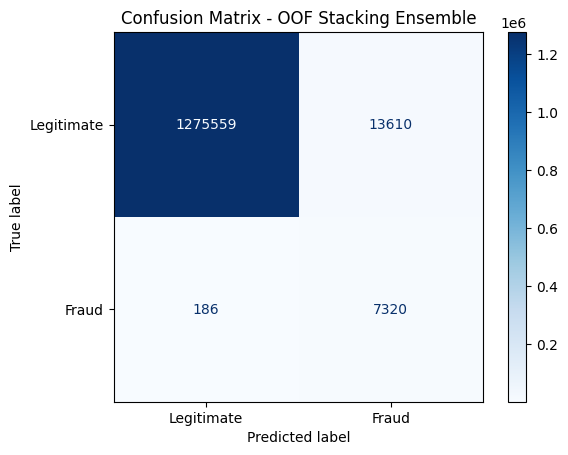

OOF Stacking Ensemble confusion matrix values:
TN: 1275559 FP: 13610
FN: 186 TP: 7320
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/oof_stacking_ensemble_confusion_matrix_normalized_true.png


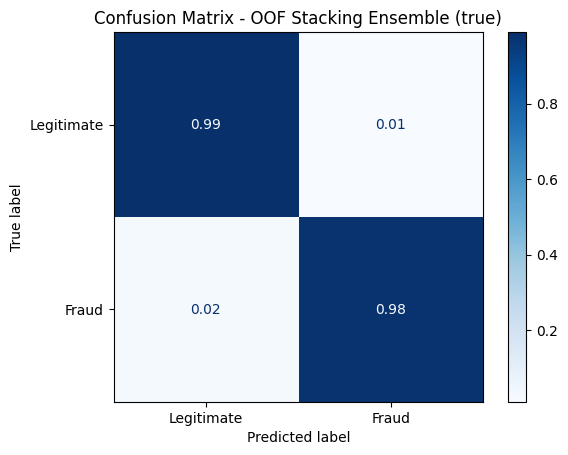

{'Precision': 0.3497372193024367,
 'Recall': 0.9752198241406874,
 'F1': 0.5148403432268955,
 'Balanced Accuracy': np.float64(0.9823313178751684),
 'ROC-AUC': np.float64(0.9986640288698011),
 'PR-AUC': np.float64(0.9217655358771253),
 'TP': 7320,
 'FP': 13610,
 'FN': 186,
 'TN': 1275559,
 'False Alarm Rate': 0.010557188390350683}

time: 1.87 s (started: 2026-06-12 08:09:57 +00:00)


In [ ]:
meta_oof_prob = meta_model.predict_proba(X_meta_train)[:, 1]

meta_oof_scores, meta_oof_pred = evaluate_predictions(
    model_name="OOF Stacking Ensemble",
    y_true=y_meta_train,
    y_prob=meta_oof_prob,
    threshold=THRESHOLD,
    save_prefix="oof_stacking_ensemble"
)

meta_oof_scores

## Meta Model Coefficients

Logistic Regression allows us to inspect how much the stacking layer trusts each base model.

A positive coefficient means that higher probability from that model pushes the final prediction toward fraud.

The coefficients are not the only measure of importance, but they give a useful explanation of the ensemble behavior.

In [ ]:
meta_importance_df = pd.DataFrame({
    "Meta Feature": X_meta_train.columns,
    "Coefficient": meta_model.coef_[0]
})

meta_importance_df["Absolute Coefficient"] = meta_importance_df["Coefficient"].abs()

meta_importance_df = meta_importance_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

meta_importance_df

,Meta Feature,Coefficient,Absolute Coefficient
2,cat_prob,5.053871,5.053871
1,lgbm_prob,4.546487,4.546487
3,xgb_prob,1.774920,1.774920
4,nn_prob,0.755679,0.755679
0,rf_prob,-0.298839,0.298839


time: 11.4 ms (started: 2026-06-12 08:09:59 +00:00)


## Save Meta Model and Meta Importance

In [ ]:
meta_model_path = os.path.join(
    MODELS_DIR,
    "stacking_meta_model.joblib"
)

joblib.dump(
    meta_model,
    meta_model_path
)

meta_importance_path = os.path.join(
    REPORTS_DIR,
    "meta_model_coefficients.csv"
)

meta_importance_df.to_csv(
    meta_importance_path,
    index=False
)

print("Saved meta model:", meta_model_path)
print("Saved meta coefficients:", meta_importance_path)

Saved meta model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/stacking_meta_model.joblib
Saved meta coefficients: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/reports/meta_model_coefficients.csv
time: 21.8 ms (started: 2026-06-12 08:09:59 +00:00)


# Final Preprocessing on Full Training Data

After generating the OOF predictions and training the meta-model, the base models are retrained using the full training dataset.

These final models are later used to generate the test meta-features and serve as the production models.

In [ ]:
X_train_final, final_preprocessing_artifacts = fit_preprocessing(
    X_train_raw_model
)

X_test_final = transform_with_preprocessing(
    X_test_raw_model,
    final_preprocessing_artifacts
)

final_preprocessing_artifacts["label_names"] = LABELS

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

preprocessing_path = os.path.join(
    PREPROCESSING_DIR,
    "preprocessing_artifacts.joblib"
)

joblib.dump(
    final_preprocessing_artifacts,
    preprocessing_path
)

feature_columns_path = os.path.join(
    BACKEND_DIR,
    "feature_columns.json"
)

with open(feature_columns_path, "w") as f:
    json.dump(
        final_preprocessing_artifacts["feature_columns"],
        f,
        indent=4
    )

print("Saved preprocessing artifacts:", preprocessing_path)
print("Saved feature columns:", feature_columns_path)

Final train shape: (1296675, 16)
Final test shape: (555719, 16)
Saved preprocessing artifacts: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/preprocessing/preprocessing_artifacts.joblib
Saved feature columns: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/backend_ready/feature_columns.json
time: 2.35 s (started: 2026-06-12 08:09:59 +00:00)


## Retrain Random Forest

Training Final Random Forest
Random Forest
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.94      0.72      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.86      0.91    555719
weighted avg       1.00      1.00      1.00    555719

{'Precision': 0.9432580841976815, 'Recall': 0.7207459207459207, 'F1': 0.8171247357293869, 'Balanced Accuracy': np.float64(0.8602889607631521), 'ROC-AUC': np.float64(0.9867241615856976), 'PR-AUC': np.float64(0.8670685043348978), 'TP': 1546, 'FP': 93, 'FN': 599, 'TN': 553481, 'False Alarm Rate': 0.00016799921961652823}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/random_forest_confusion_matrix.png


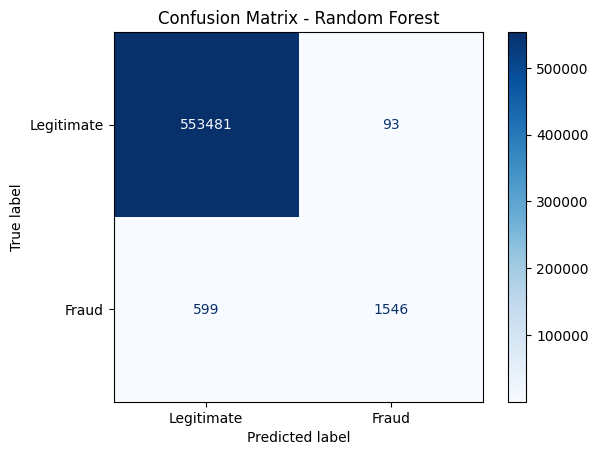

Random Forest confusion matrix values:
TN: 553481 FP: 93
FN: 599 TP: 1546
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/random_forest_confusion_matrix_normalized_true.png


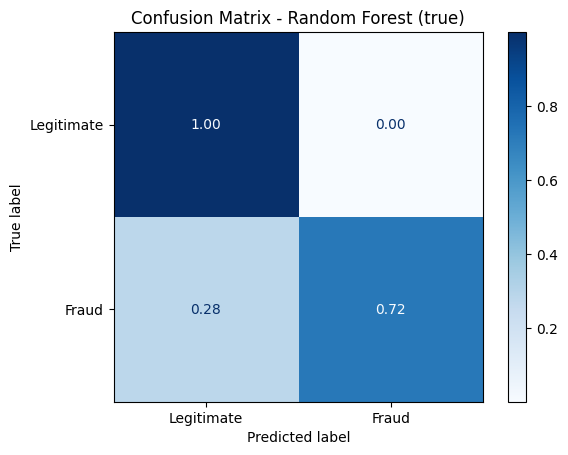

time: 2min 44s (started: 2026-06-12 08:10:01 +00:00)


In [ ]:
final_results = {}

print("=" * 80)
print("Training Final Random Forest")
print("=" * 80)

start_time = time.time()

final_rf_model = build_random_forest()

final_rf_model.fit(
    X_train_final,
    y_train_model
)

rf_training_time = time.time() - start_time

start_time = time.time()

rf_test_prob = final_rf_model.predict_proba(
    X_test_final
)[:, 1]

rf_inference_time = time.time() - start_time

rf_scores, rf_test_pred = evaluate_predictions(
    model_name="Random Forest",
    y_true=y_test_model,
    y_prob=rf_test_prob,
    threshold=THRESHOLD,
    save_prefix="final_random_forest"
)

final_results["Random Forest"] = {
    "model": final_rf_model,
    "y_prob": rf_test_prob,
    "y_pred": rf_test_pred,
    "scores": rf_scores,
    "training_time_seconds": rf_training_time,
    "inference_time_seconds": rf_inference_time,
}

## Retrain LightGBM

Training Final LightGBM
LightGBM
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.46      0.90      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.95      0.80    555719
weighted avg       1.00      1.00      1.00    555719

{'Precision': 0.4564029460679496, 'Recall': 0.8955710955710956, 'F1': 0.6046584828454517, 'Balanced Accuracy': np.float64(0.9457189767399423), 'ROC-AUC': np.float64(0.9966552486822586), 'PR-AUC': np.float64(0.8713767052341349), 'TP': 1921, 'FP': 2288, 'FN': 224, 'TN': 551286, 'False Alarm Rate': 0.004133142091210931}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/lightgbm_confusion_matrix.png


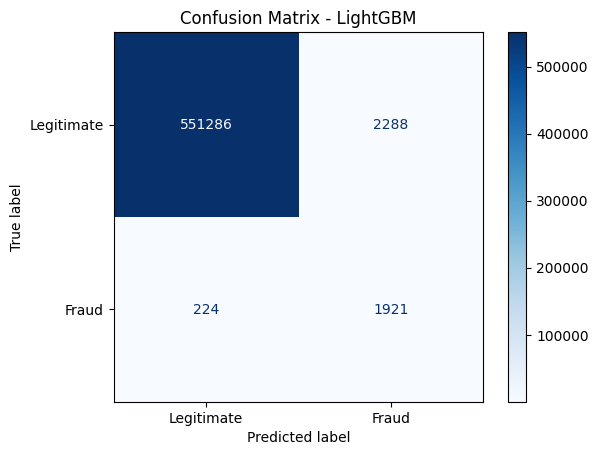

LightGBM confusion matrix values:
TN: 551286 FP: 2288
FN: 224 TP: 1921
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/lightgbm_confusion_matrix_normalized_true.png


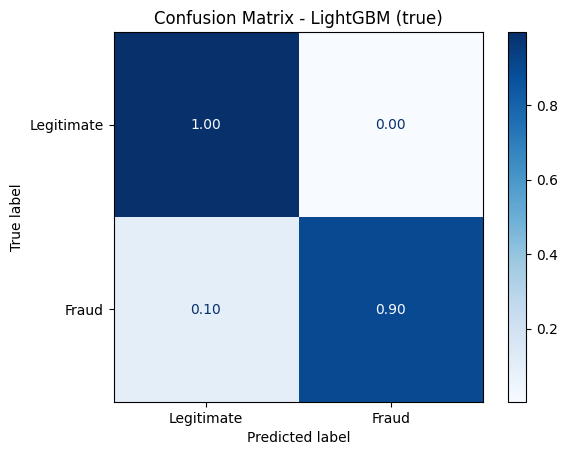

time: 20 s (started: 2026-06-12 08:12:45 +00:00)


In [ ]:
print("=" * 80)
print("Training Final LightGBM")
print("=" * 80)

start_time = time.time()

final_lgbm_model = build_lightgbm()

final_lgbm_model.fit(
    X_train_final,
    y_train_model
)

lgbm_training_time = time.time() - start_time

start_time = time.time()

lgbm_test_prob = final_lgbm_model.predict_proba(
    X_test_final
)[:, 1]

lgbm_inference_time = time.time() - start_time

lgbm_scores, lgbm_test_pred = evaluate_predictions(
    model_name="LightGBM",
    y_true=y_test_model,
    y_prob=lgbm_test_prob,
    threshold=THRESHOLD,
    save_prefix="final_lightgbm"
)

final_results["LightGBM"] = {
    "model": final_lgbm_model,
    "y_prob": lgbm_test_prob,
    "y_pred": lgbm_test_pred,
    "scores": lgbm_scores,
    "training_time_seconds": lgbm_training_time,
    "inference_time_seconds": lgbm_inference_time,
}

## Retrain CatBoost

Training Final CatBoost
CatBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.30      0.95      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719

{'Precision': 0.29568251199302226, 'Recall': 0.9482517482517483, 'F1': 0.4507978723404255, 'Balanced Accuracy': np.float64(0.9697497654213468), 'ROC-AUC': np.float64(0.997062305607866), 'PR-AUC': np.float64(0.8693632076760471), 'TP': 2034, 'FP': 4845, 'FN': 111, 'TN': 548729, 'False Alarm Rate': 0.008752217409054616}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/catboost_confusion_matrix.png


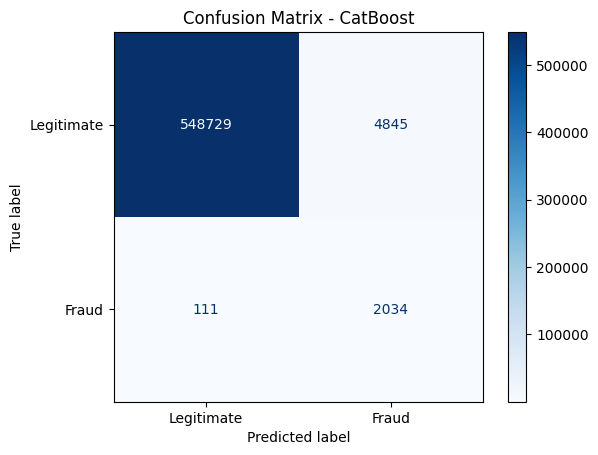

CatBoost confusion matrix values:
TN: 548729 FP: 4845
FN: 111 TP: 2034
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/catboost_confusion_matrix_normalized_true.png


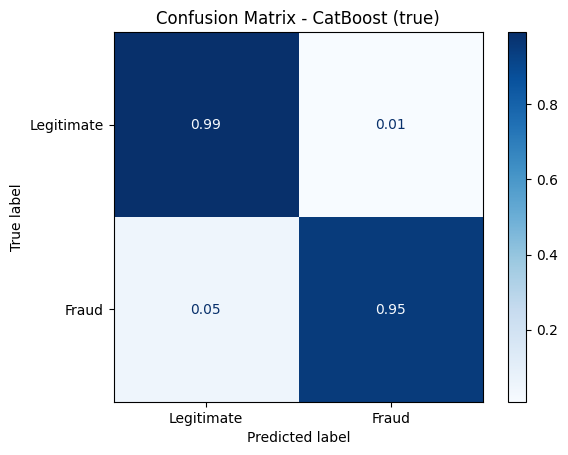

time: 1min 18s (started: 2026-06-12 08:13:05 +00:00)


In [ ]:
print("=" * 80)
print("Training Final CatBoost")
print("=" * 80)

start_time = time.time()

final_cat_model = build_catboost()

final_cat_model.fit(
    X_train_final,
    y_train_model
)

cat_training_time = time.time() - start_time

start_time = time.time()

cat_test_prob = final_cat_model.predict_proba(
    X_test_final
)[:, 1]

cat_inference_time = time.time() - start_time

cat_scores, cat_test_pred = evaluate_predictions(
    model_name="CatBoost",
    y_true=y_test_model,
    y_prob=cat_test_prob,
    threshold=THRESHOLD,
    save_prefix="final_catboost"
)

final_results["CatBoost"] = {
    "model": final_cat_model,
    "y_prob": cat_test_prob,
    "y_pred": cat_test_pred,
    "scores": cat_scores,
    "training_time_seconds": cat_training_time,
    "inference_time_seconds": cat_inference_time,
}

## Retrain XGBoost



Training Final XGBoost
Final scale_pos_weight: 171.75179856115108
XGBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.94      0.47      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.96      0.73    555719
weighted avg       1.00      0.99      0.99    555719

{'Precision': 0.3122572627000155, 'Recall': 0.9370629370629371, 'F1': 0.46842227918900026, 'Balanced Accuracy': np.float64(0.964532906460273), 'ROC-AUC': np.float64(0.9970784675900884), 'PR-AUC': np.float64(0.8711830128472388), 'TP': 2010, 'FP': 4427, 'FN': 135, 'TN': 549147, 'False Alarm Rate': 0.007997124142391081}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/xgboost_confusion_matrix.png


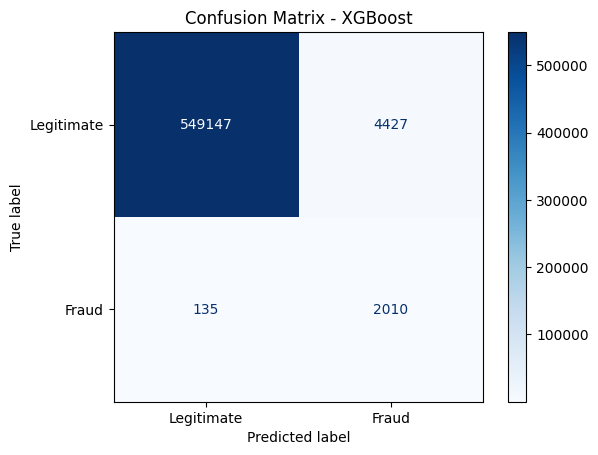

XGBoost confusion matrix values:
TN: 549147 FP: 4427
FN: 135 TP: 2010
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/xgboost_confusion_matrix_normalized_true.png


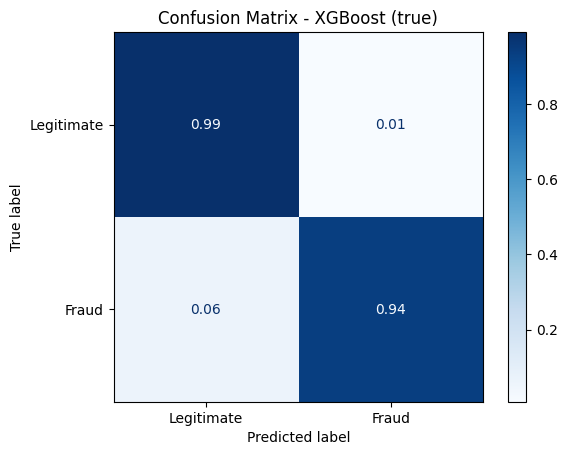

time: 12.7 s (started: 2026-06-12 08:14:24 +00:00)


In [ ]:
print("=" * 80)
print("Training Final XGBoost")
print("=" * 80)

final_pos_weight = (
    (y_train_model == 0).sum()
    /
    max((y_train_model == 1).sum(), 1)
)

print("Final scale_pos_weight:", final_pos_weight)

start_time = time.time()

final_xgb_model = build_xgboost(
    pos_weight=final_pos_weight
)

final_xgb_model.fit(
    X_train_final,
    y_train_model
)

xgb_training_time = time.time() - start_time

start_time = time.time()

xgb_test_prob = final_xgb_model.predict_proba(
    X_test_final
)[:, 1]

xgb_inference_time = time.time() - start_time

xgb_scores, xgb_test_pred = evaluate_predictions(
    model_name="XGBoost",
    y_true=y_test_model,
    y_prob=xgb_test_prob,
    threshold=THRESHOLD,
    save_prefix="final_xgboost"
)

final_results["XGBoost"] = {
    "model": final_xgb_model,
    "y_prob": xgb_test_prob,
    "y_pred": xgb_test_pred,
    "scores": xgb_scores,
    "training_time_seconds": xgb_training_time,
    "inference_time_seconds": xgb_inference_time,
}

## Retrain Neural Network



Training Final Neural Network
Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4678 - pr_auc: 0.1612 - roc_auc: 0.8440
Epoch 1: val_pr_auc improved from None to 0.23393, saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/best_nn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/best_nn.keras
254/254 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.4057 - pr_auc: 0.1921 - roc_auc: 0.8870 - val_loss: 0.3661 - val_pr_auc: 0.2339 - val_roc_auc: 0.9384 - learning_rate: 0.0010
Epoch 2/50
248/254 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3422 - pr_auc: 0.2254 - roc_auc: 0.9253
Epoch 2: val_pr_auc improved from 0.23393 to 0.25157, saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/best_nn.keras

Epoch 2: finished sa

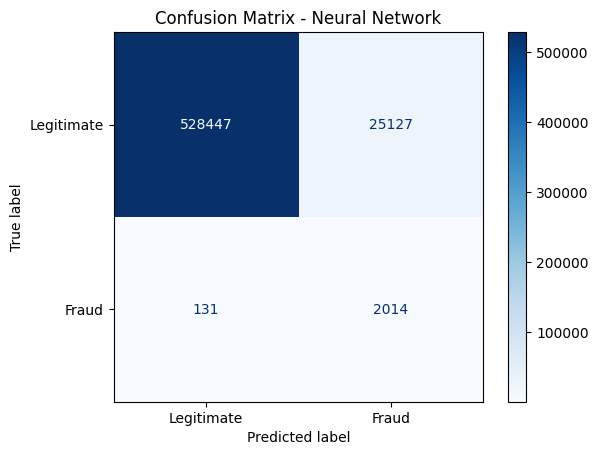

Neural Network confusion matrix values:
TN: 528447 FP: 25127
FN: 131 TP: 2014
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/neural_network_confusion_matrix_normalized_true.png


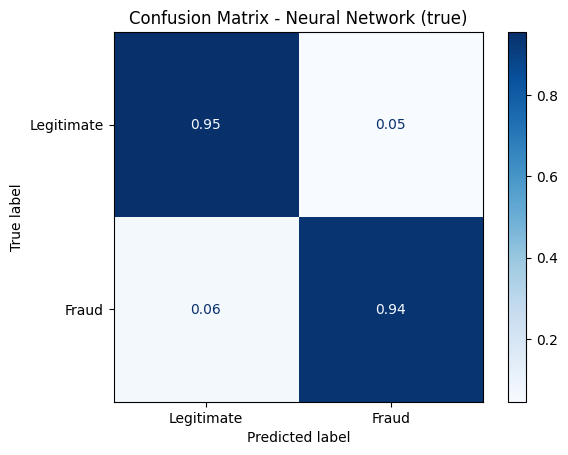

time: 47.8 s (started: 2026-06-12 08:14:36 +00:00)


In [ ]:
print("=" * 80)
print("Training Final Neural Network")
print("=" * 80)

final_nn_scaler = StandardScaler()

X_train_final_nn = final_nn_scaler.fit_transform(X_train_final)
X_test_final_nn = final_nn_scaler.transform(X_test_final)

classes = np.unique(y_train_model)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_model
)

final_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

final_nn_model = build_neural_network(
    input_dim=X_train_final_nn.shape[1]
)

final_nn_path = os.path.join(
    MODELS_DIR,
    "best_nn.keras"
)

final_training_log_path = os.path.join(
    REPORTS_DIR,
    "final_neural_network_training_log.csv"
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=final_nn_path,
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

csv_logger = keras.callbacks.CSVLogger(
    final_training_log_path
)

start_time = time.time()

final_nn_history = final_nn_model.fit(
    X_train_final_nn,
    y_train_model,
    validation_split=0.20,
    epochs=NN_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=final_class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint,
        csv_logger
    ],
    verbose=1
)

nn_training_time = time.time() - start_time

final_nn_model = keras.models.load_model(
    final_nn_path
)

start_time = time.time()

nn_test_prob = final_nn_model.predict(
    X_test_final_nn,
    batch_size=8192,
    verbose=0
).flatten()

nn_inference_time = time.time() - start_time

nn_scores, nn_test_pred = evaluate_predictions(
    model_name="Neural Network",
    y_true=y_test_model,
    y_prob=nn_test_prob,
    threshold=THRESHOLD,
    save_prefix="final_neural_network"
)

final_results["Neural Network"] = {
    "model": final_nn_model,
    "y_prob": nn_test_prob,
    "y_pred": nn_test_pred,
    "scores": nn_scores,
    "training_time_seconds": nn_training_time,
    "inference_time_seconds": nn_inference_time,
}

### Save Final NN Scaler

In [ ]:
final_nn_scaler_path = os.path.join(
    PREPROCESSING_DIR,
    "neural_network_scaler.joblib"
)

joblib.dump(
    final_nn_scaler,
    final_nn_scaler_path
)

print("Saved final neural network scaler:", final_nn_scaler_path)

Saved final neural network scaler: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/preprocessing/neural_network_scaler.joblib
time: 5.98 ms (started: 2026-06-12 08:15:24 +00:00)


## Build Test Meta Features

Now we create the test meta-dataset.

Each final base model predicts probabilities on the untouched test set.

These probabilities become the test features for the Logistic Regression meta-model.

In [ ]:
meta_test_df = pd.DataFrame({
    "rf_prob": rf_test_prob,
    "lgbm_prob": lgbm_test_prob,
    "cat_prob": cat_test_prob,
    "xgb_prob": xgb_test_prob,
    "nn_prob": nn_test_prob,
    "label": y_test_model.values
})

meta_test_df.head()

,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,label
0,0.0,0.000360,0.000317,0.000304,0.020924,0
1,0.0,0.001150,0.001293,0.007654,0.020370,0
2,0.0,0.000143,0.000918,0.000497,0.014765,0
3,0.0,0.000085,0.000151,0.000329,0.002329,0
4,0.0,0.000460,0.001691,0.001084,0.023558,0


time: 13 ms (started: 2026-06-12 08:15:24 +00:00)


## Final Stacking Ensemble Prediction

The stacking ensemble now predicts fraud probabilities on the final test set.

This is the main result of the notebook.

The test set was not used during OOF generation or meta-model training.

Stacking Ensemble
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99    553574
       Fraud       0.27      0.95      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.97      0.71    555719
weighted avg       1.00      0.99      0.99    555719

{'Precision': 0.27401849122336863, 'Recall': 0.9533799533799534, 'F1': 0.42568692756036636, 'Balanced Accuracy': np.float64(0.9717963220024373), 'ROC-AUC': np.float64(0.9971299769079289), 'PR-AUC': np.float64(0.8626440447636861), 'TP': 2045, 'FP': 5418, 'FN': 100, 'TN': 548156, 'False Alarm Rate': 0.009787309375079031}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/stacking_ensemble_confusion_matrix.png


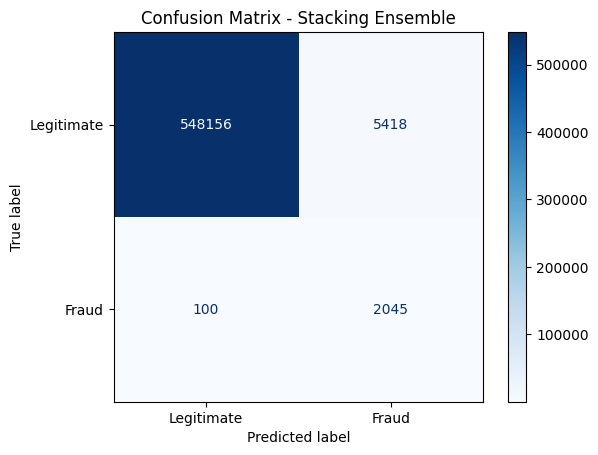

Stacking Ensemble confusion matrix values:
TN: 548156 FP: 5418
FN: 100 TP: 2045
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/stacking_ensemble_confusion_matrix_normalized_true.png


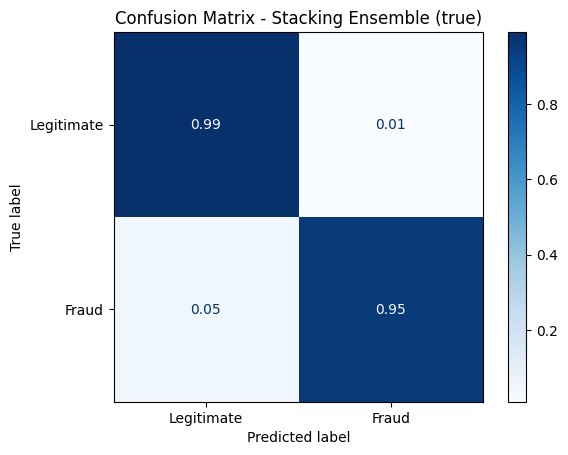

{'Precision': 0.27401849122336863,
 'Recall': 0.9533799533799534,
 'F1': 0.42568692756036636,
 'Balanced Accuracy': np.float64(0.9717963220024373),
 'ROC-AUC': np.float64(0.9971299769079289),
 'PR-AUC': np.float64(0.8626440447636861),
 'TP': 2045,
 'FP': 5418,
 'FN': 100,
 'TN': 548156,
 'False Alarm Rate': 0.009787309375079031}

time: 1.07 s (started: 2026-06-12 08:15:24 +00:00)


In [ ]:
X_meta_test = meta_test_df[
    ["rf_prob", "lgbm_prob", "cat_prob", "xgb_prob", "nn_prob"]
]

stacking_test_prob = meta_model.predict_proba(
    X_meta_test
)[:, 1]

stacking_scores, stacking_test_pred = evaluate_predictions(
    model_name="Stacking Ensemble",
    y_true=y_test_model,
    y_prob=stacking_test_prob,
    threshold=THRESHOLD,
    save_prefix="stacking_ensemble"
)

final_results["Stacking Ensemble"] = {
    "model": meta_model,
    "y_prob": stacking_test_prob,
    "y_pred": stacking_test_pred,
    "scores": stacking_scores,
    "training_time_seconds": None,
    "inference_time_seconds": None,
}

stacking_scores

## Optional Threshold Optimization

The default evaluation threshold is 0.5.

For fraud detection, alternative thresholds may provide a better balance between precision and recall.

The threshold below is selected using the OOF predictions and evaluated on the final test set.

Best production threshold from OOF: 0.9990673180660194
Best OOF F1: 0.8872148985143335
Stacking Ensemble - OOF Optimized Threshold
Threshold: 0.9990673180660194
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.90      0.76      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.88      0.91    555719
weighted avg       1.00      1.00      1.00    555719

{'Precision': 0.900990099009901, 'Recall': 0.7636363636363637, 'F1': 0.8266464799394398, 'Balanced Accuracy': np.float64(0.8816556019282303), 'ROC-AUC': np.float64(0.9971299769079289), 'PR-AUC': np.float64(0.8626440447636861), 'TP': 1638, 'FP': 180, 'FN': 507, 'TN': 553394, 'False Alarm Rate': 0.00032515977990295786}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/stacking_ensemble___oof_optimized_threshold_confusion_matrix.pn

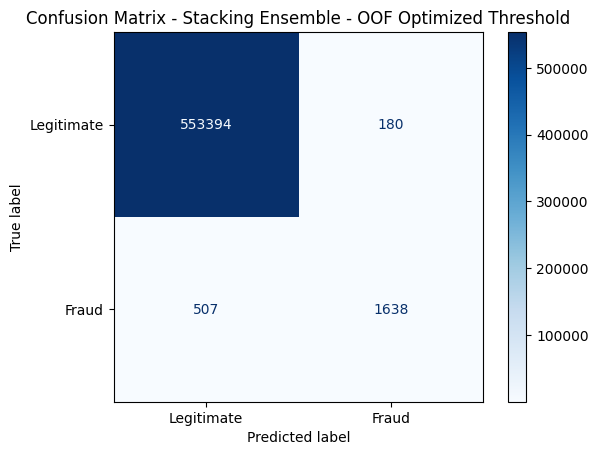

Stacking Ensemble - OOF Optimized Threshold confusion matrix values:
TN: 553394 FP: 180
FN: 507 TP: 1638
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/stacking_ensemble___oof_optimized_threshold_confusion_matrix_normalized_true.png


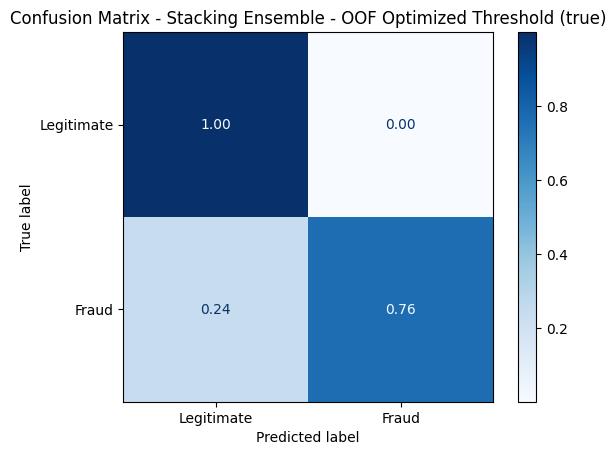

time: 1.29 s (started: 2026-06-12 08:15:25 +00:00)


In [ ]:
best_threshold, best_f1 = optimize_threshold_by_f1(
    y_meta_train,
    meta_oof_prob
)

print("Best production threshold from OOF:", best_threshold)
print("Best OOF F1:", best_f1)

stacking_opt_scores, stacking_opt_pred = evaluate_predictions(
    model_name="Stacking Ensemble - OOF Optimized Threshold",
    y_true=y_test_model,
    y_prob=stacking_test_prob,
    threshold=best_threshold,
    save_prefix="stacking_ensemble_oof_optimized_threshold"
)

## Final Model Comparison

This table compares the standalone base models with the final stacking ensemble.

The most important question is whether the ensemble improves the tradeoff between:

- catching fraud cases
- reducing false alarms
- improving PR-AUC
- improving F1-score

In [ ]:
comparison_df = pd.DataFrame({
    model_name: result["scores"]
    for model_name, result in final_results.items()
}).T

comparison_df["Training Time (sec)"] = [
    final_results[m]["training_time_seconds"]
    for m in comparison_df.index
]

comparison_df["Inference Time (sec)"] = [
    final_results[m]["inference_time_seconds"]
    for m in comparison_df.index
]

comparison_df["Threshold"] = THRESHOLD

comparison_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
)

comparison_df

,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TP,FP,FN,TN,False Alarm Rate,Training Time (sec),Inference Time (sec),Threshold
LightGBM,0.456403,0.895571,0.604658,0.945719,0.996655,0.871377,1921.0,2288.0,224.0,551286.0,0.004133,17.021433,2.019687,0.5
XGBoost,0.312257,0.937063,0.468422,0.964533,0.997078,0.871183,2010.0,4427.0,135.0,549147.0,0.007997,11.140585,0.600618,0.5
CatBoost,0.295683,0.948252,0.450798,0.969750,0.997062,0.869363,2034.0,4845.0,111.0,548729.0,0.008752,77.262948,0.066333,0.5
Random Forest,0.943258,0.720746,0.817125,0.860289,0.986724,0.867069,1546.0,93.0,599.0,553481.0,0.000168,162.170884,1.397648,0.5
Stacking Ensemble,0.274018,0.953380,0.425687,0.971796,0.997130,0.862644,2045.0,5418.0,100.0,548156.0,0.009787,NaN,NaN,0.5
Neural Network,0.074205,0.938928,0.137540,0.946769,0.986671,0.689777,2014.0,25127.0,131.0,528447.0,0.045390,43.454188,2.316066,0.5


time: 29.2 ms (started: 2026-06-12 08:15:27 +00:00)


## Save Final Comparison Table

In [ ]:
comparison_path = os.path.join(
    REPORTS_DIR,
    "final_model_comparison_metrics.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=True
)

print("Saved:", comparison_path)

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/reports/final_model_comparison_metrics.csv
time: 6.52 ms (started: 2026-06-12 08:15:27 +00:00)


## Visual Model Comparison

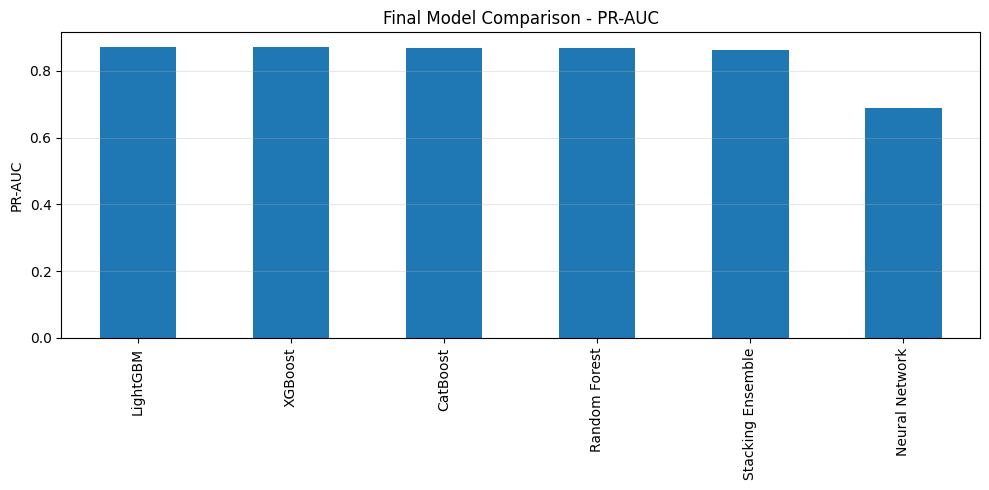

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_pr_auc.png


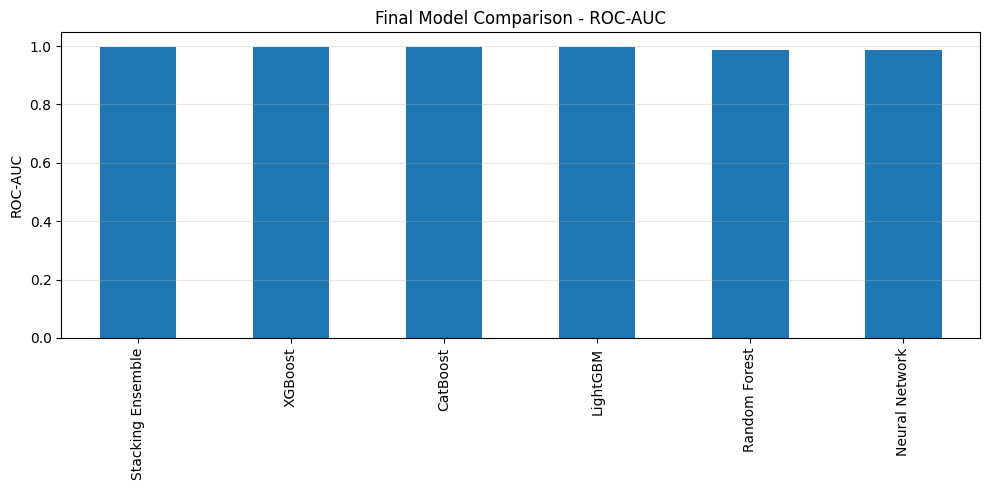

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_roc_auc.png


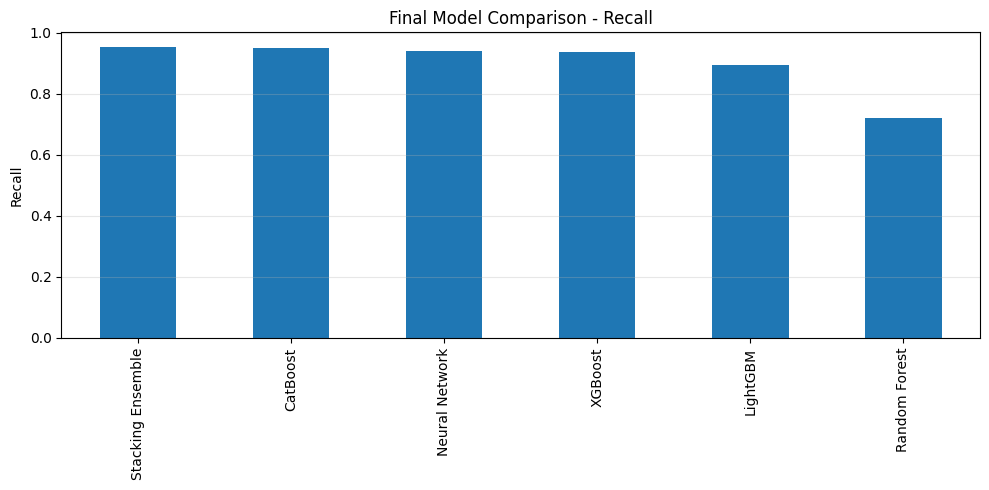

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_recall.png


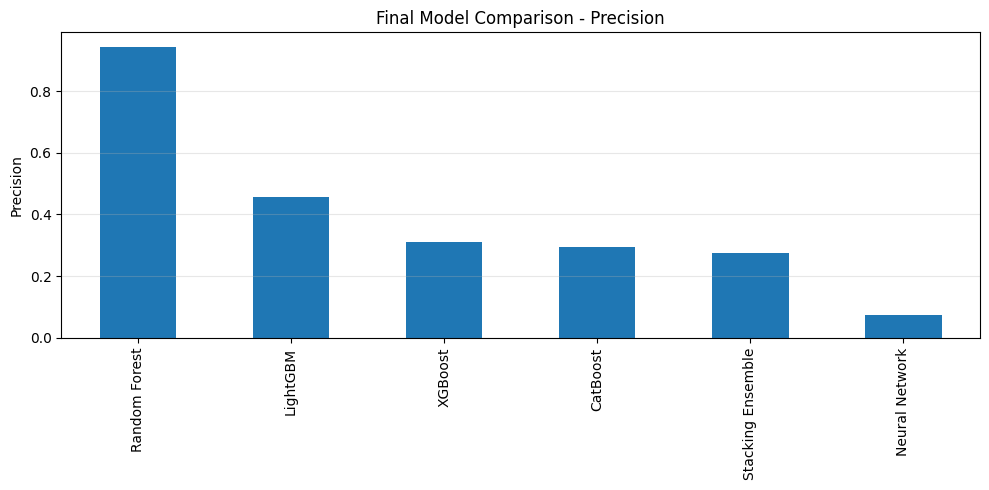

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_precision.png


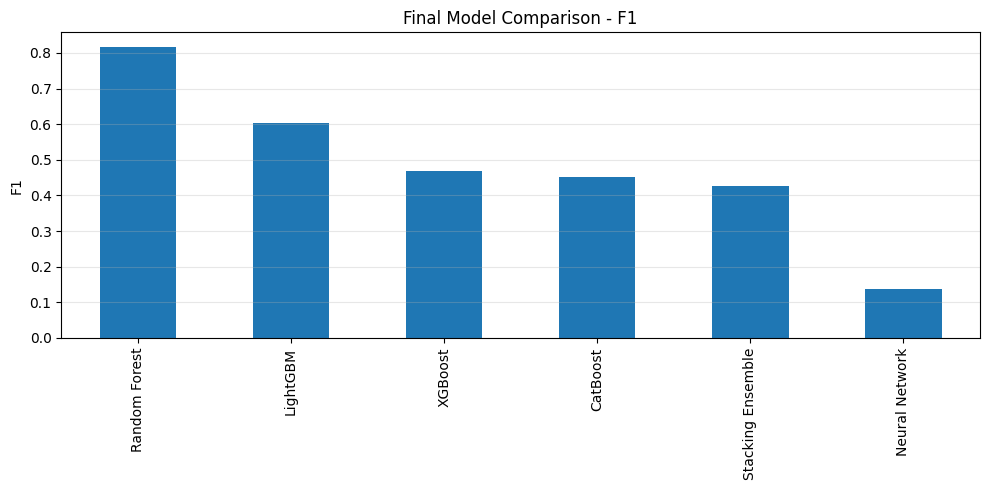

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_f1.png


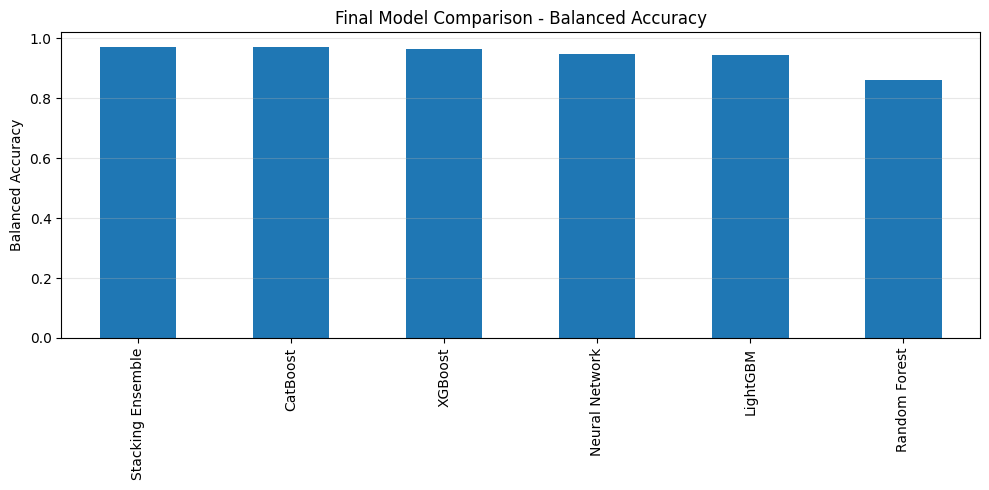

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/final_model_comparison_balanced_accuracy.png
time: 1.83 s (started: 2026-06-12 08:15:27 +00:00)


In [ ]:
metrics_to_plot = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Precision",
    "F1",
    "Balanced Accuracy",
]

for metric in metrics_to_plot:

    plt.figure(figsize=(10, 5))

    comparison_df[metric] \
        .sort_values(ascending=False) \
        .plot(kind="bar")

    plt.title(f"Final Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    figure_path = os.path.join(
        FIGURES_DIR,
        f"final_model_comparison_{clean_model_name(metric)}.png"
    )

    plt.savefig(
        figure_path,
        bbox_inches="tight",
        dpi=150
    )

    plt.show()

    print("Saved:", figure_path)

## ROC Curve Comparison

ROC-AUC measures how well each model separates fraud from legitimate transactions across all thresholds.

In fraud detection, ROC-AUC is useful, but PR-AUC is often more important because the dataset is highly imbalanced.

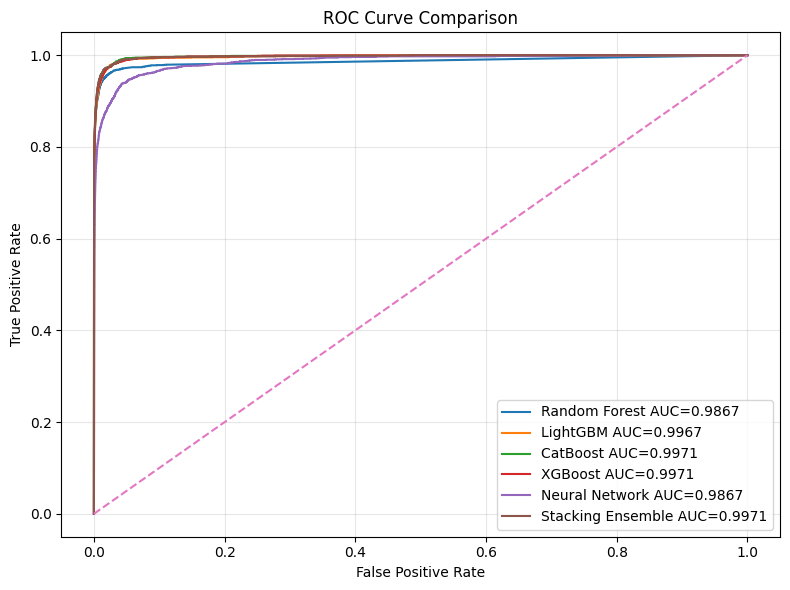

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/roc_curve_comparison.png
time: 1.84 s (started: 2026-06-12 08:15:28 +00:00)


In [ ]:
plt.figure(figsize=(8, 6))

for model_name, result in final_results.items():
    fpr, tpr, _ = roc_curve(
        y_test_model,
        result["y_prob"]
    )

    auc_score = roc_auc_score(
        y_test_model,
        result["y_prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={auc_score:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(
    FIGURES_DIR,
    "roc_curve_comparison.png"
)

plt.savefig(
    roc_path,
    bbox_inches="tight",
    dpi=150
)

plt.show()

print("Saved:", roc_path)

## Precision-Recall Curve Comparison

Precision-Recall curves are especially important for fraud detection.

Because fraud is rare, PR-AUC gives a clearer picture of model quality than accuracy.

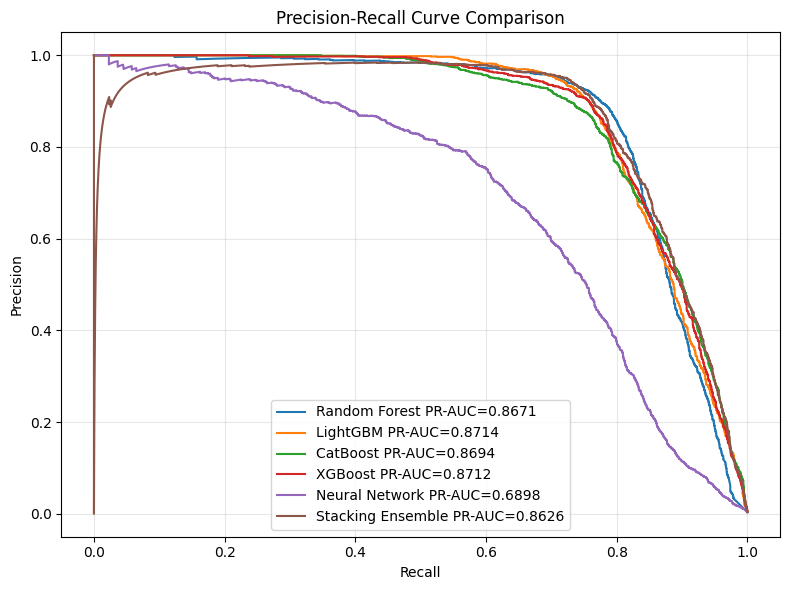

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/figures/precision_recall_curve_comparison.png
time: 17.4 s (started: 2026-06-12 08:15:30 +00:00)


In [ ]:
plt.figure(figsize=(8, 6))

for model_name, result in final_results.items():
    precision, recall, _ = precision_recall_curve(
        y_test_model,
        result["y_prob"]
    )

    pr_auc = average_precision_score(
        y_test_model,
        result["y_prob"]
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} PR-AUC={pr_auc:.4f}"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(
    FIGURES_DIR,
    "precision_recall_curve_comparison.png"
)

plt.savefig(
    pr_path,
    bbox_inches="tight",
    dpi=150
)

plt.show()

print("Saved:", pr_path)

## Save Final Predictions

In [ ]:
final_predictions_df = pd.DataFrame({
    "y_true": y_test_model.values,
    "rf_prob": rf_test_prob,
    "lgbm_prob": lgbm_test_prob,
    "cat_prob": cat_test_prob,
    "xgb_prob": xgb_test_prob,
    "nn_prob": nn_test_prob,
    "stacking_prob": stacking_test_prob,
    "stacking_pred": stacking_test_pred,
    "stacking_pred_optimized": stacking_opt_pred
})

final_predictions_path = os.path.join(
    PREDICTIONS_DIR,
    "final_stacking_predictions.csv"
)

final_predictions_df.to_csv(
    final_predictions_path,
    index=False
)

meta_test_path = os.path.join(
    PREDICTIONS_DIR,
    "test_meta_features.csv"
)

meta_test_df.to_csv(
    meta_test_path,
    index=False
)

print("Saved final predictions:", final_predictions_path)
print("Saved test meta features:", meta_test_path)

Saved final predictions: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/predictions/final_stacking_predictions.csv
Saved test meta features: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/predictions/test_meta_features.csv
time: 8.87 s (started: 2026-06-12 08:15:48 +00:00)


## Save Final Production Artifacts

The final production package includes:

- All five base models
- Logistic Regression meta-model
- preprocessing artifacts
- neural network scaler
- feature columns
- final predictions
- reports
- figures

These artifacts allow the ensemble to be reused later in a backend or production inference notebook.

In [ ]:
rf_path = os.path.join(MODELS_DIR, "random_forest.joblib")
lgbm_path = os.path.join(MODELS_DIR, "lightgbm.joblib")
cat_path = os.path.join(MODELS_DIR, "catboost.cbm")
xgb_path = os.path.join(MODELS_DIR, "xgboost.json")

joblib.dump(final_rf_model, rf_path)
joblib.dump(final_lgbm_model, lgbm_path)

final_cat_model.save_model(cat_path)
final_xgb_model.save_model(xgb_path)

print("Saved Random Forest:", rf_path)
print("Saved LightGBM:", lgbm_path)
print("Saved CatBoost:", cat_path)
print("Saved XGBoost:", xgb_path)
print("Saved Neural Network:", final_nn_path)
print("Saved Meta Model:", meta_model_path)

Saved Random Forest: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/random_forest.joblib
Saved LightGBM: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/lightgbm.joblib
Saved CatBoost: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/catboost.cbm
Saved XGBoost: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/xgboost.json
Saved Neural Network: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/best_nn.keras
Saved Meta Model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/stacking_meta_model.joblib
time: 611 ms (started: 2026-06-12 08:15:57 +00:00)


## Save Final Metrics JSON

In [ ]:
final_metrics_payload = {
    "saved_at": datetime.now().isoformat(),
    "threshold": float(THRESHOLD),
    "optimized_threshold": float(best_threshold),
    "models": {}
}

for model_name, result in final_results.items():
    final_metrics_payload["models"][model_name] = {
        "scores": {
            k: float(v)
            for k, v in result["scores"].items()
        },
        "training_time_seconds": (
            None
            if result["training_time_seconds"] is None
            else float(result["training_time_seconds"])
        ),
        "inference_time_seconds": (
            None
            if result["inference_time_seconds"] is None
            else float(result["inference_time_seconds"])
        )
    }

final_metrics_payload["stacking_optimized_threshold_scores"] = {
    k: float(v)
    for k, v in stacking_opt_scores.items()
}

final_metrics_path = os.path.join(
    REPORTS_DIR,
    "final_metrics_summary.json"
)

with open(final_metrics_path, "w") as f:
    json.dump(
        final_metrics_payload,
        f,
        indent=4
    )

print("Saved final metrics summary:", final_metrics_path)

Saved final metrics summary: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/reports/final_metrics_summary.json
time: 5.98 ms (started: 2026-06-12 08:15:57 +00:00)


In [ ]:
production_manifest = {
    "saved_at": datetime.now().isoformat(),
    "label_names": LABELS,
    "meta_features": ["rf_prob", "lgbm_prob", "cat_prob", "xgb_prob", "nn_prob"],
    "default_threshold": float(THRESHOLD),
    "production_threshold": float(best_threshold),
    "models": {
        "random_forest": rf_path,
        "lightgbm": lgbm_path,
        "catboost": cat_path,
        "xgboost": xgb_path,
        "neural_network": final_nn_path,
        "meta_model": meta_model_path,
    },
    "preprocessing": {
        "preprocessing_artifacts": preprocessing_path,
        "neural_network_scaler": final_nn_scaler_path,
        "feature_columns": feature_columns_path,
    }
}

manifest_path = os.path.join(BACKEND_DIR, "production_manifest.json")

with open(manifest_path, "w") as f:
    json.dump(production_manifest, f, indent=4)

print("Saved production manifest:", manifest_path)

Saved production manifest: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/backend_ready/production_manifest.json
time: 416 ms (started: 2026-06-12 08:15:57 +00:00)


# Final Conclusion

An Out-Of-Fold stacking ensemble was constructed using five base models:

- Random Forest
- LightGBM
- CatBoost
- XGBoost
- Neural Network

Out-Of-Fold predictions were used to train a Logistic Regression meta-model while preventing data leakage.

After the meta-model was trained, all base models were retrained on the full training dataset and evaluated on the untouched test set.

The resulting artifacts, preprocessing objects, trained models, and metadata were saved for production inference and backend integration.